# Parkinson's Freezing of Gait: Data Exploration

This notebook explores the labeled **tDCS FoG** subset from Kaggle's *Parkinson's Freezing of Gait Prediction* competition. It uses a three-axis lower-back accelerometer sampled at 128 Hz and expert-reviewed labels for start hesitation, turning, and walking freezes.

The notebook is intentionally patient-aware: recordings are linked to subjects before any modeling so later train/test splits can keep patients separate.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FS = 128
EVENT_COLUMNS = ["StartHesitation", "Turn", "Walking"]
EVENT_LABELS = {
    "StartHesitation": "Start hesitation",
    "Turn": "Turning freeze",
    "Walking": "Walking freeze",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DIR}")

Project root: /home/mathew/Arrakis/da-mp
Raw data directory: /home/mathew/Arrakis/da-mp/data/raw


## Load metadata and discover recordings

The download is intentionally limited to the labeled `tdcsfog` training subset. The code discovers available recording files rather than assuming the entire 58.5 GB competition archive is present.

In [2]:
metadata = pd.read_csv(RAW_DIR / "tdcsfog_metadata.csv", dtype={"Id": str, "Subject": str})
subjects_raw = pd.read_csv(RAW_DIR / "subjects.csv", dtype={"Subject": str})

available_ids = {path.stem for path in RAW_DIR.glob("*.csv")}
metadata = metadata[metadata["Id"].isin(available_ids)].copy()
recording_paths = {row.Id: RAW_DIR / f"{row.Id}.csv" for row in metadata.itertuples()}

clinical_columns = ["Age", "YearsSinceDx", "UPDRSIII_On", "UPDRSIII_Off", "NFOGQ"]
clinical = subjects_raw.groupby("Subject", as_index=False)[clinical_columns].median(numeric_only=True)
sex = subjects_raw.groupby("Subject", as_index=False)["Sex"].first()
clinical = clinical.merge(sex, on="Subject", how="left")
metadata = metadata.merge(clinical, on="Subject", how="left")

summary = pd.Series({
    "recordings": len(metadata),
    "unique subjects": metadata["Subject"].nunique(),
    "on-medication recordings": metadata["Medication"].eq("on").sum(),
    "off-medication recordings": metadata["Medication"].eq("off").sum(),
})
display(summary.to_frame("value"))
display(metadata.head())

,value
recordings,506
unique subjects,60
on-medication recordings,321
off-medication recordings,185


,Id,Subject,Visit,Test,Medication,Age,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ,Sex
0,003f117e14,4dc2f8,3,2,on,68.0,9.0,17.0,15.0,15.0,F
1,009ee11563,f62eec,4,2,on,71.0,10.0,42.0,NaN,24.0,M
2,011322847a,231c3b,2,2,on,67.0,12.0,27.0,28.0,19.0,M
3,01d0fe7266,231c3b,2,1,off,67.0,12.0,27.0,28.0,19.0,M
4,024418ba39,fa8764,19,3,on,60.0,7.0,30.0,NaN,19.0,F


## Cohort characteristics

Clinical variables are summarized once per subject. Where the source table contains more than one visit, the subject median is used only for this descriptive view.

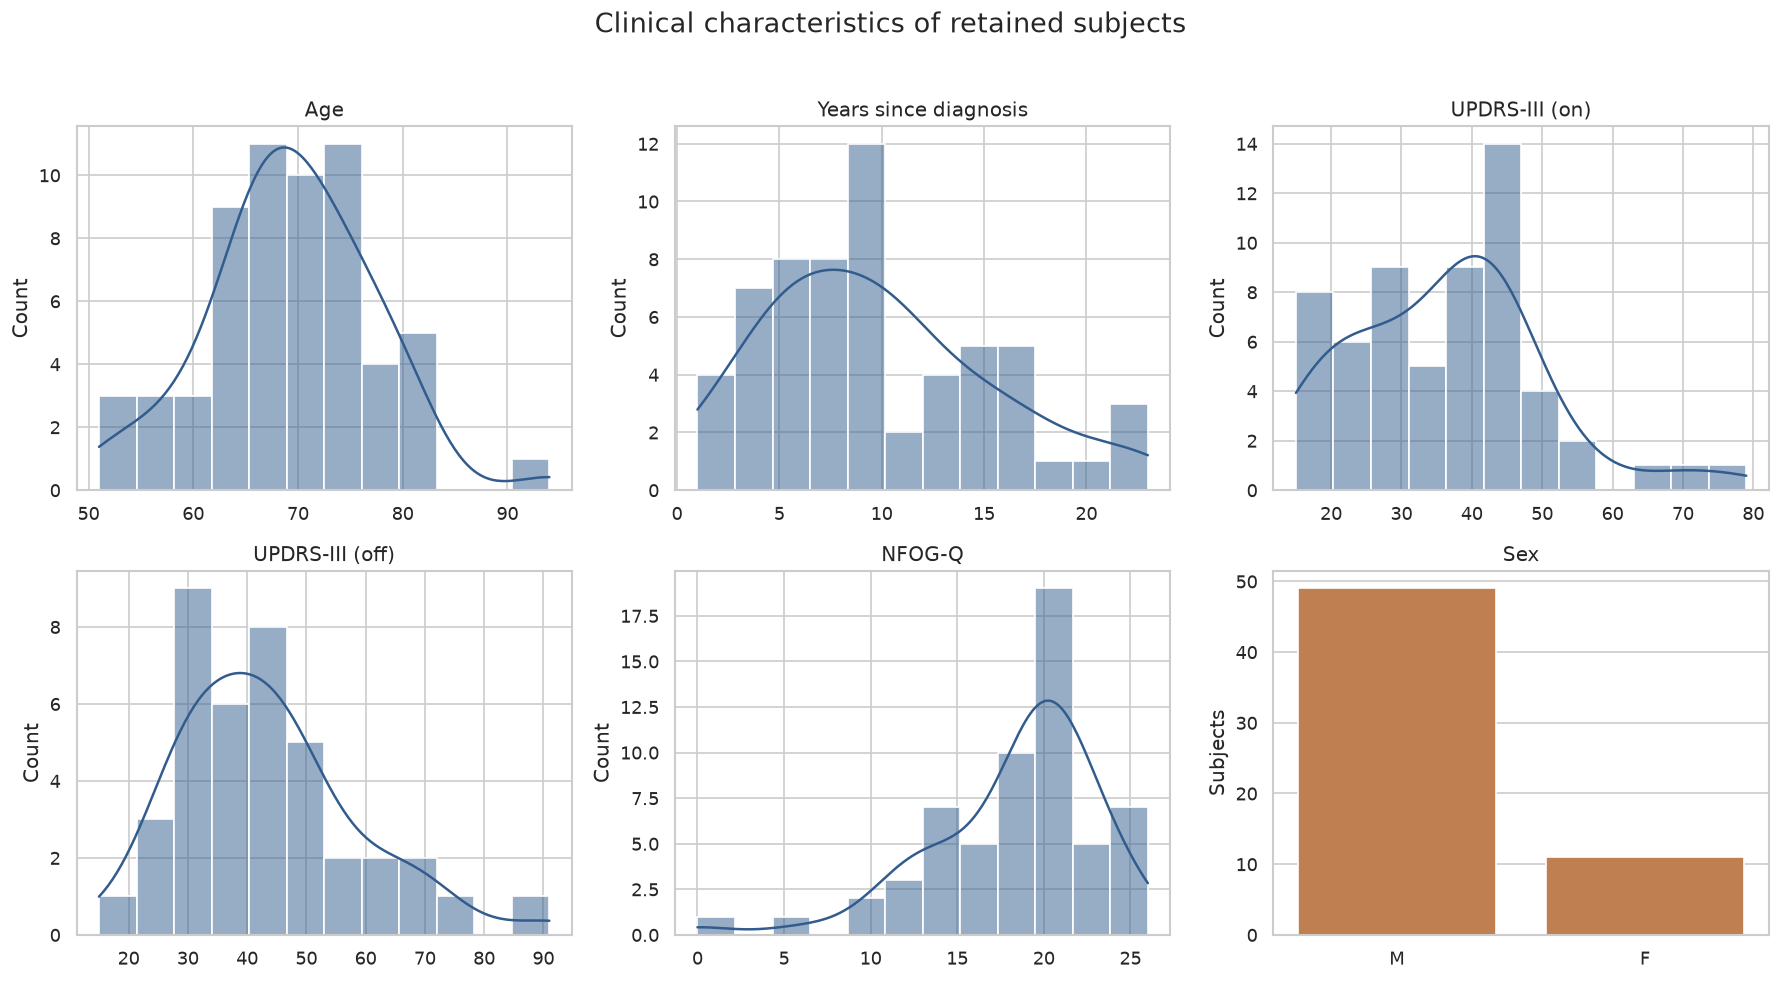

In [3]:
cohort = clinical[clinical["Subject"].isin(metadata["Subject"])].copy()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, column, title in zip(
    axes.flat,
    ["Age", "YearsSinceDx", "UPDRSIII_On", "UPDRSIII_Off", "NFOGQ"],
    ["Age", "Years since diagnosis", "UPDRS-III (on)", "UPDRS-III (off)", "NFOG-Q"],
):
    sns.histplot(cohort[column].dropna(), bins=12, kde=True, ax=ax, color="#315c8d")
    ax.set_title(title)
    ax.set_xlabel("")
sex_counts = cohort["Sex"].value_counts()
sns.barplot(x=sex_counts.index, y=sex_counts.values, ax=axes.flat[-1], color="#d17c3f")
axes.flat[-1].set(title="Sex", xlabel="", ylabel="Subjects")
fig.suptitle("Clinical characteristics of retained subjects", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Label prevalence and episode burden

Accuracy alone would be misleading because freezing occupies a small fraction of total recording time. The plots below quantify the imbalance and the distribution of FoG burden across recordings.

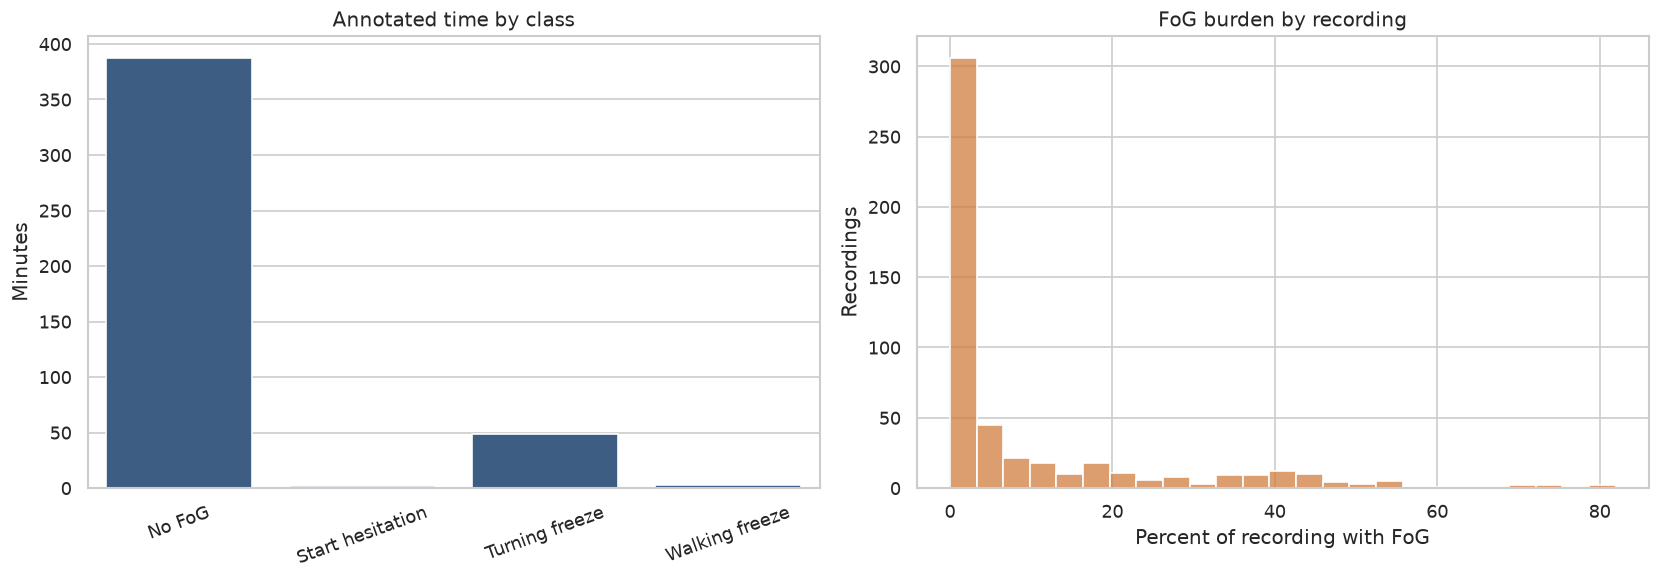

,seconds,percent
No FoG,23248.46,87.90
Start hesitation,110.63,0.42
Turning freeze,2904.12,10.98
Walking freeze,185.73,0.70


In [4]:
recording_rows = []
for recording_id, path in recording_paths.items():
    labels = pd.read_csv(path, usecols=EVENT_COLUMNS, dtype={column: "int8" for column in EVENT_COLUMNS})
    any_fog = labels.any(axis=1)
    row = {
        "Id": recording_id,
        "samples": len(labels),
        "duration_s": len(labels) / FS,
        "NoFoG_s": (~any_fog).sum() / FS,
        "FoG_s": any_fog.sum() / FS,
    }
    for column in EVENT_COLUMNS:
        row[f"{column}_s"] = labels[column].sum() / FS
        row[f"{column}_episodes"] = ((labels[column].diff().fillna(labels[column]) == 1)).sum()
    recording_rows.append(row)

recording_summary = pd.DataFrame(recording_rows).merge(metadata, on="Id", how="left")
recording_summary["FoG_burden_pct"] = 100 * recording_summary["FoG_s"] / recording_summary["duration_s"]
recording_summary.to_csv(PROCESSED_DIR / "recording_summary.csv", index=False)

class_seconds = pd.Series({
    "No FoG": recording_summary["NoFoG_s"].sum(),
    **{EVENT_LABELS[column]: recording_summary[f"{column}_s"].sum() for column in EVENT_COLUMNS},
})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=class_seconds.index, y=class_seconds.values / 60, ax=axes[0], color="#315c8d")
axes[0].set(title="Annotated time by class", xlabel="", ylabel="Minutes")
axes[0].tick_params(axis="x", rotation=20)
sns.histplot(recording_summary["FoG_burden_pct"], bins=25, ax=axes[1], color="#d17c3f")
axes[1].set(title="FoG burden by recording", xlabel="Percent of recording with FoG", ylabel="Recordings")
fig.tight_layout()
plt.show()

display(class_seconds.rename("seconds").to_frame().assign(percent=lambda x: 100 * x["seconds"] / x["seconds"].sum()).round(2))

## Example accelerometer trace

The highlighted regions are expert-reviewed FoG labels. A short interval around the first event is shown so differences in amplitude and periodicity remain visible.

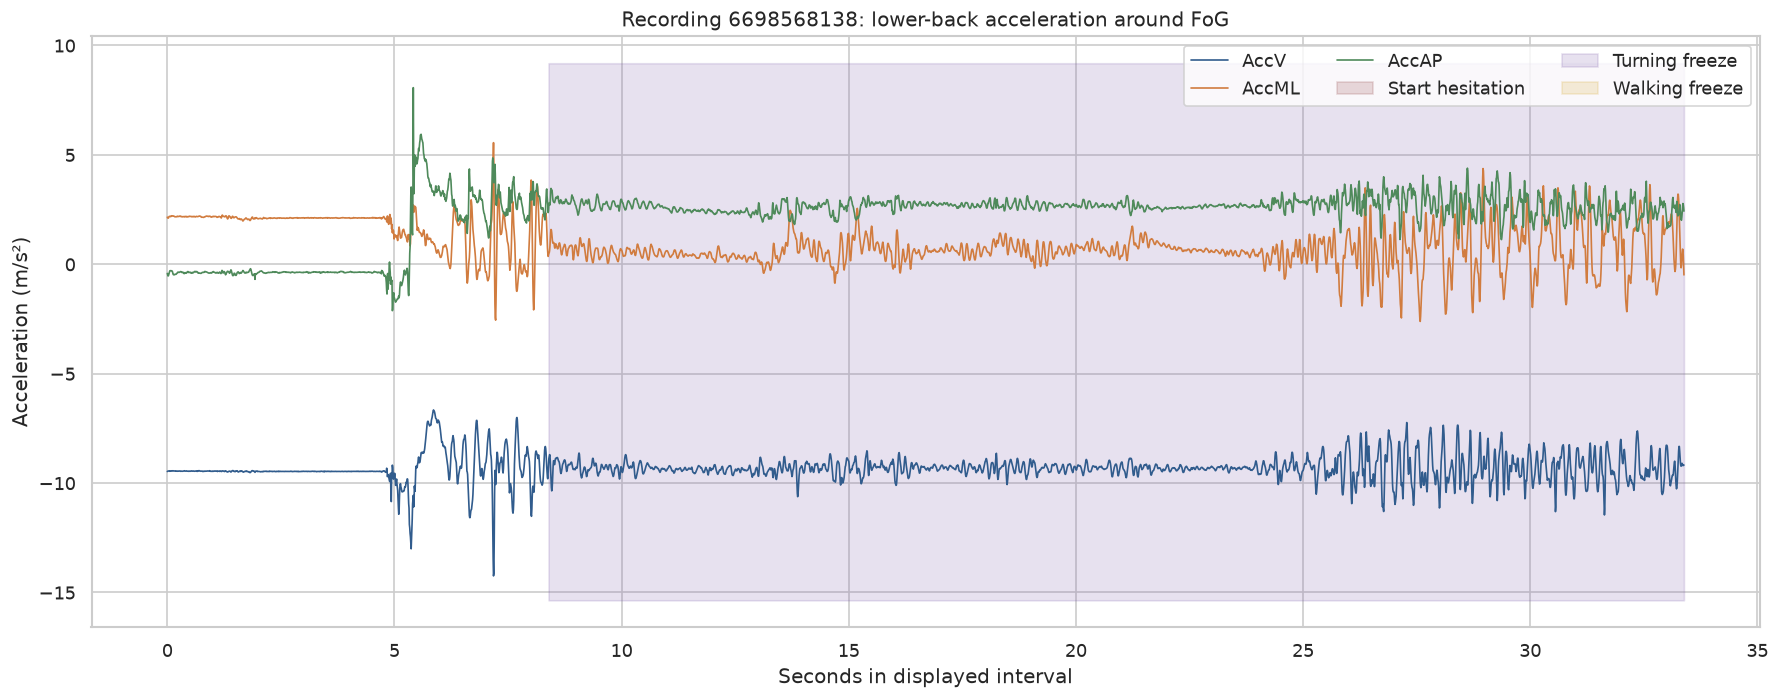

In [5]:
example_id = recording_summary.sort_values("FoG_s", ascending=False).iloc[0]["Id"]
example = pd.read_csv(recording_paths[example_id])
first_event = np.flatnonzero(example[EVENT_COLUMNS].any(axis=1).to_numpy())[0]
start = max(0, first_event - 10 * FS)
end = min(len(example), first_event + 25 * FS)
segment = example.iloc[start:end].copy()
segment["seconds"] = np.arange(len(segment)) / FS

fig, ax = plt.subplots(figsize=(15, 6))
for column, color in zip(["AccV", "AccML", "AccAP"], ["#315c8d", "#d17c3f", "#4f8a5b"]):
    ax.plot(segment["seconds"], segment[column], label=column, linewidth=1, color=color)
colors = {"StartHesitation": "#8c3b3b", "Turn": "#7c5caa", "Walking": "#d4a72c"}
for column in EVENT_COLUMNS:
    mask = segment[column].astype(bool).to_numpy()
    ax.fill_between(segment["seconds"], *ax.get_ylim(), where=mask, alpha=0.18, color=colors[column], label=EVENT_LABELS[column])
ax.set(title=f"Recording {example_id}: lower-back acceleration around FoG", xlabel="Seconds in displayed interval", ylabel="Acceleration (m/s²)")
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

## Exploratory clinical associations

These are descriptive, subject-level associations—not evidence that FoG burden is a complete measure of Parkinson's severity. Medication state, task mix, and repeated visits are potential confounders.

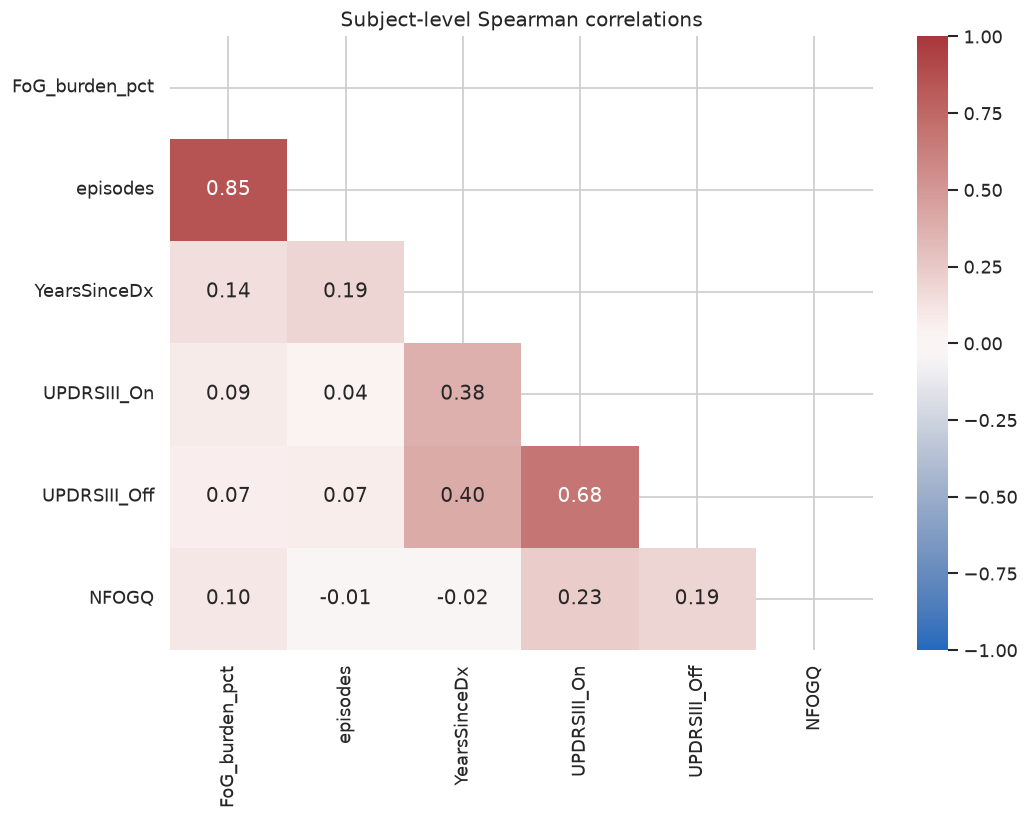

,Subject,duration_s,FoG_s,episodes,FoG_burden_pct,Age,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ,Sex
34,79011a,326.296875,249.421875,19,76.440167,73.0,7.0,37.0,46.0,20.0,M
17,48fd62,268.546875,113.273438,12,42.180136,81.0,1.0,42.0,30.0,16.0,M
44,b19f77,337.742188,141.695312,16,41.953691,82.0,15.0,54.0,68.0,21.0,F
10,2c98f7,459.070312,190.007812,27,41.389697,73.0,1.0,30.0,32.0,20.0,M
7,24a59d,377.062500,153.031250,29,40.585115,77.0,1.0,37.0,39.0,21.0,M
41,a03db7,584.617188,203.773438,19,34.855875,56.0,11.0,27.0,55.0,19.0,M
21,4ca9b3,576.687500,193.117188,17,33.487320,74.0,7.0,20.0,32.0,23.0,M
51,d9312a,1187.421875,386.929688,57,32.585696,61.0,21.0,38.0,39.0,19.0,M
46,c7fee4,59.750000,16.843750,2,28.190377,80.0,12.0,52.0,NaN,12.0,M
28,5c0b8a,120.593750,33.359375,8,27.662607,76.0,17.0,79.0,NaN,24.0,M


In [6]:
recording_summary["episodes"] = recording_summary[[f"{column}_episodes" for column in EVENT_COLUMNS]].sum(axis=1)
subject_burden = recording_summary.groupby("Subject", as_index=False).agg(
    duration_s=("duration_s", "sum"),
    FoG_s=("FoG_s", "sum"),
    episodes=("episodes", "sum"),
)
subject_burden["FoG_burden_pct"] = 100 * subject_burden["FoG_s"] / subject_burden["duration_s"]
subject_burden = subject_burden.merge(clinical, on="Subject", how="left")

association_columns = ["FoG_burden_pct", "episodes", "YearsSinceDx", "UPDRSIII_On", "UPDRSIII_Off", "NFOGQ"]
spearman = subject_burden[association_columns].corr(method="spearman")
mask = np.triu(np.ones_like(spearman, dtype=bool))
plt.figure(figsize=(9, 7))
sns.heatmap(spearman, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Subject-level Spearman correlations")
plt.tight_layout()
plt.show()

display(subject_burden.sort_values("FoG_burden_pct", ascending=False).head(10))

## Modeling implications

- The outcome is imbalanced, so macro F1, balanced accuracy, per-class recall, and precision–recall curves are more informative than raw accuracy.
- Windows from the same person are correlated. The model notebook therefore splits and cross-validates by **subject**, never by random window.
- The primary target is FoG event type. UPDRS and NFOG-Q are retained for secondary descriptive analysis; the notebook does not claim that event detection is equivalent to clinical severity assessment.
- The next notebook extracts time- and frequency-domain features from two-second windows and compares a class-prior baseline, balanced logistic regression, and balanced random forest.